In [1]:
# Cell 1: Dual video generation with interactive run selection
from pathlib import Path
import sys
import gymnasium as gym
from stable_baselines3 import PPO
import imageio.v2 as imageio
from IPython.display import Video, display
import torch

# If True, regenerate video even when file already exists
FORCE_REGENERATE_VIDEO = False

start_dir = Path.cwd().resolve()
project_root = next((p for p in [start_dir, *start_dir.parents] if (p / "core").is_dir()), start_dir)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from core.train_manager import TrainManager

device = "cuda" if torch.cuda.is_available() else "cpu"
root_log_dir = project_root / "logs_and_results"

def safe_input(prompt, default=""):
    try:
        raw = input(prompt).strip()
        return raw if raw else default
    except EOFError:
        return default

def choose_single_run(manager, algo_name):
    run_ids = manager.list_run_ids()
    if not run_ids:
        return None
    print(f"{algo_name} available runs: {run_ids}")
    raw = safe_input(f"Choose one {algo_name} run id for video (Enter = latest {run_ids[-1]}): ", default=str(run_ids[-1]))
    if not raw.isdigit():
        raise ValueError(f"Invalid run id input: {raw}")
    run_id = int(raw)
    if run_id not in run_ids:
        raise ValueError(f"run_{run_id} not found under {manager.algo_dir}")
    return run_id

def resolve_paths(algo_name, model_stem, video_name, selected_run_id=None):
    manager = TrainManager(base_dir=root_log_dir, algo_name=algo_name)
    run_id = selected_run_id if selected_run_id is not None else choose_single_run(manager, algo_name)

    # Backward compatibility for old single-file layout
    if run_id is None:
        fallback_model = root_log_dir / f"{model_stem}.zip"
        fallback_video = root_log_dir / video_name
        return fallback_model, fallback_video, f"{algo_name} (legacy)"

    paths = manager.get_run_paths(run_id=run_id, create=False)
    model_path = paths["models_dir"] / f"{model_stem}.zip"
    video_path = paths["videos_dir"] / video_name
    return model_path, video_path, f"{algo_name} run_{run_id}"

def generate_or_load_video(model_path, video_path, title_text):
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    if video_path.exists() and not FORCE_REGENERATE_VIDEO:
        print(f"Use existing video: {video_path}")
    else:
        print(f"Generate video for {title_text}...")
        video_env = gym.make("MountainCar-v0", render_mode="rgb_array")
        model = PPO.load(str(model_path), device=device)

        obs, _ = video_env.reset()
        terminated, truncated = False, False
        frames = []

        while not (terminated or truncated):
            frames.append(video_env.render())
            action, _ = model.predict(obs, deterministic=True)
            obs, _, terminated, truncated, _ = video_env.step(action)

        video_path.parent.mkdir(parents=True, exist_ok=True)
        imageio.mimsave(str(video_path), frames, fps=30)
        video_env.close()
        print(f"Saved video to {video_path}")

    print(f"\n--- {title_text} Demo ---")
    display(Video(str(video_path), embed=True))

baseline_model_path, baseline_video_path, baseline_title = resolve_paths(
    algo_name="baseline",
    model_stem="baseline_multi_thresh",
    video_name="baseline_multi_thresh_demo.mp4",
)
vlm_model_path, vlm_video_path, vlm_title = resolve_paths(
    algo_name="vlm",
    model_stem="vlm_multi_thresh",
    video_name="vlm_multi_thresh_demo.mp4",
)

generate_or_load_video(baseline_model_path, baseline_video_path, baseline_title)
generate_or_load_video(vlm_model_path, vlm_video_path, vlm_title)

baseline available runs: [1, 2, 3, 4, 5]
vlm available runs: [1, 2, 3, 4, 5]
Use existing video: D:\CodeFiles\RL-Gymnasium-PACSPL602013-Final-Project\logs_and_results\baseline\run_5\videos\baseline_multi_thresh_demo.mp4

--- baseline run_5 Demo ---


Generate video for vlm run_5...


d:\CodeFiles\RL-Gymnasium-PACSPL602013-Final-Project\final_project_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved video to D:\CodeFiles\RL-Gymnasium-PACSPL602013-Final-Project\logs_and_results\vlm\run_5\videos\vlm_multi_thresh_demo.mp4

--- vlm run_5 Demo ---


Baseline runs: [1, 2, 3, 4, 5]
VLM runs: [1, 2, 3, 4, 5]
Common runs: [1, 2, 3, 4, 5]
Selected common runs: [1]
Average runs (shared by baseline and vlm): [1]


,Run,Threshold,Steps
0,1,-195,210795
1,1,-190,232156
2,1,-180,600000
3,1,-170,600000
4,1,-160,600000


,Run,Threshold,Steps
0,1,-195,53541
1,1,-190,53541
2,1,-180,53541
3,1,-170,53541
4,1,-160,53541


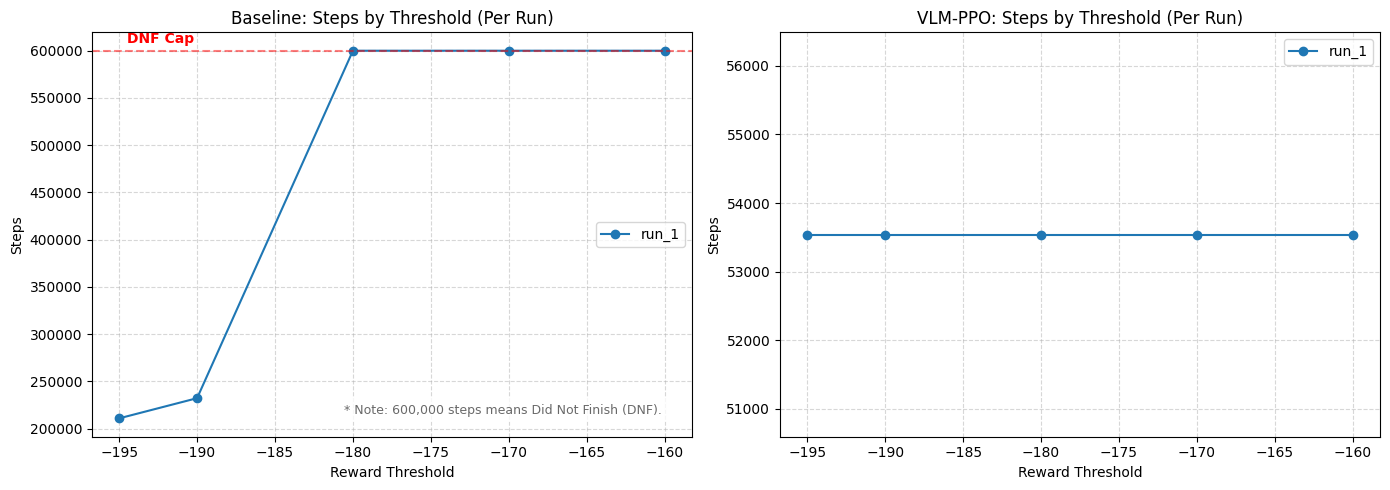

,Threshold,Baseline_Mean,VLM_Mean,Speedup
0,-195,210795.0,53541.0,3.937076
1,-190,232156.0,53541.0,4.336042
2,-180,600000.0,53541.0,11.206365
3,-170,600000.0,53541.0,11.206365
4,-160,600000.0,53541.0,11.206365


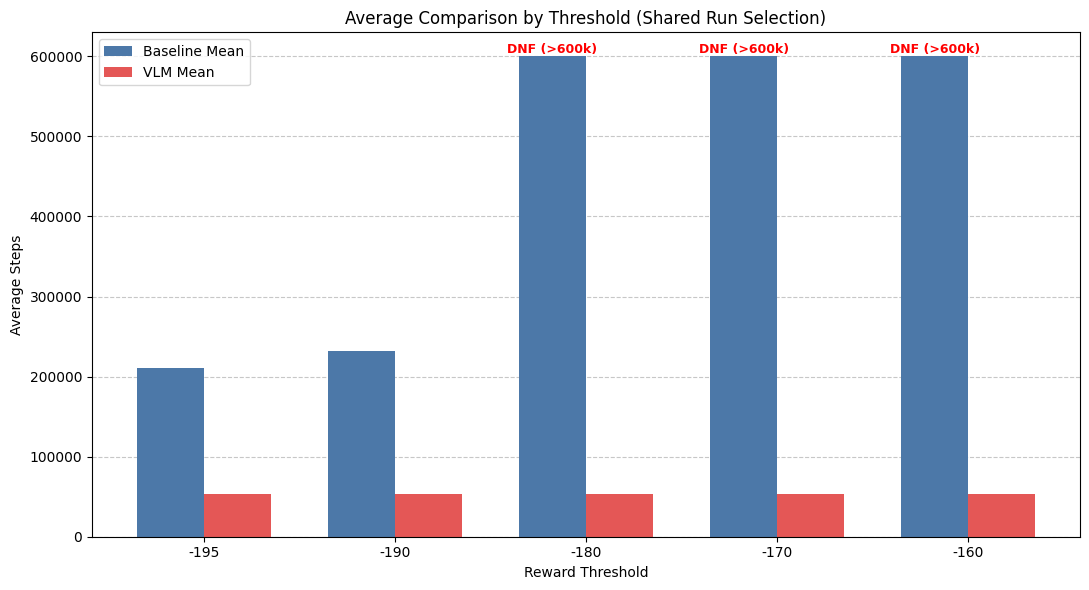

In [10]:
# Cell 2: Interactive run comparison with unified selection range and DNF labels
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = [-195, -190, -180, -170, -160]
baseline_dnf_cap = 600000
vlm_dnf_cap = 150000

start_dir = Path.cwd().resolve()
project_root = next((p for p in [start_dir, *start_dir.parents] if (p / "core").is_dir()), start_dir)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from core.train_manager import TrainManager

root_log_dir = project_root / "logs_and_results"
baseline_manager = TrainManager(base_dir=root_log_dir, algo_name="baseline")
vlm_manager = TrainManager(base_dir=root_log_dir, algo_name="vlm")

def safe_input(prompt, default=""):
    try:
        raw = input(prompt).strip()
        return raw if raw else default
    except EOFError:
        return default

def parse_ids_or_range(raw):
    raw = raw.strip()
    if raw == "":
        return None
    if "-" in raw:
        left, right = raw.split("-", 1)
        if left.strip().isdigit() and right.strip().isdigit():
            lo = min(int(left.strip()), int(right.strip()))
            hi = max(int(left.strip()), int(right.strip()))
            return list(range(lo, hi + 1))
    parts = [p.strip() for p in raw.split(",") if p.strip()]
    if parts and all(p.isdigit() for p in parts):
        return [int(p) for p in parts]
    raise ValueError(f"Invalid input: {raw}. Use '1-3' or '1,2,3'.")

def normalize_steps(raw_value, dnf_cap):
    if raw_value is None:
        return int(dnf_cap)
    return int(raw_value)

def load_thresholds_for_runs(manager, run_ids, dnf_cap):
    data = manager.load_run_data(run_ids=run_ids)
    rows = []
    for rid in run_ids:
        item = data.get(rid, {})
        thresholds_map = item.get("thresholds", {})
        for t in thresholds:
            key = str(t)
            value = normalize_steps(thresholds_map.get(key), dnf_cap)
            rows.append({
                "Run": int(rid),
                "Threshold": int(t),
                "Steps": int(value),
            })
    return pd.DataFrame(rows)

baseline_all = baseline_manager.list_run_ids()
vlm_all = vlm_manager.list_run_ids()
common_runs = sorted(set(baseline_all).intersection(vlm_all))
print(f"Baseline runs: {baseline_all}")
print(f"VLM runs: {vlm_all}")
print(f"Common runs: {common_runs}")

if not common_runs:
    # Backward compatibility for old single-file layout
    baseline_json = root_log_dir / "baseline_thresholds.json"
    vlm_json = root_log_dir / "vlm_thresholds.json"
    if not baseline_json.exists() or not vlm_json.exists():
        raise FileNotFoundError("No common run folders and no legacy JSON files found.")

    with open(baseline_json, "r", encoding="utf-8") as f:
        baseline_raw = json.load(f)
    with open(vlm_json, "r", encoding="utf-8") as f:
        vlm_raw = json.load(f)

    baseline_df = pd.DataFrame(
        [{"Run": 0, "Threshold": t, "Steps": normalize_steps(baseline_raw.get(str(t)), baseline_dnf_cap)} for t in thresholds]
    )
    vlm_df = pd.DataFrame(
        [{"Run": 0, "Threshold": t, "Steps": normalize_steps(vlm_raw.get(str(t)), vlm_dnf_cap)} for t in thresholds]
    )
else:
    raw_selected = safe_input(
        "Select common runs for comparison (Enter=all common, e.g. 1-3 or 1,2,4): ",
        default="",
    )
    selected_runs = parse_ids_or_range(raw_selected) if raw_selected else common_runs
    selected_runs = [rid for rid in selected_runs if rid in common_runs]
    if not selected_runs:
        raise ValueError("No valid common runs selected.")
    print(f"Selected common runs: {selected_runs}")

    raw_avg = safe_input(
        "Select ONE common run range/list for average (Enter=use selected runs): ",
        default="",
    )
    avg_runs = parse_ids_or_range(raw_avg) if raw_avg else selected_runs
    avg_runs = [rid for rid in avg_runs if rid in selected_runs]
    if not avg_runs:
        raise ValueError("No valid average runs selected.")
    print(f"Average runs (shared by baseline and vlm): {avg_runs}")

    baseline_df = load_thresholds_for_runs(baseline_manager, selected_runs, baseline_dnf_cap)
    vlm_df = load_thresholds_for_runs(vlm_manager, selected_runs, vlm_dnf_cap)

display(baseline_df.head(20))
display(vlm_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
if not baseline_df.empty:
    for run_id, grp in baseline_df.groupby("Run"):
        grp_sorted = grp.sort_values("Threshold")
        axes[0].plot(grp_sorted["Threshold"], grp_sorted["Steps"], marker="o", label=f"run_{run_id}")
axes[0].set_title("Baseline: Steps by Threshold (Per Run)")
axes[0].set_xlabel("Reward Threshold")
axes[0].set_ylabel("Steps")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="best")
# --- Add DNF guide line and note for baseline plot ---
axes[0].axhline(y=baseline_dnf_cap, color='red', linestyle='--', alpha=0.5)
axes[0].text(-194.5, baseline_dnf_cap + 8000, 'DNF Cap', color='red', fontsize=10, fontweight='bold')
axes[0].text(0.95, 0.05, '* Note: 600,000 steps means Did Not Finish (DNF).',
             transform=axes[0].transAxes, ha='right', va='bottom',
             fontsize=9, color='dimgray',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
# -----------------------------------------------------

if not vlm_df.empty:
    for run_id, grp in vlm_df.groupby("Run"):
        grp_sorted = grp.sort_values("Threshold")
        axes[1].plot(grp_sorted["Threshold"], grp_sorted["Steps"], marker="o", label=f"run_{run_id}")
axes[1].set_title("VLM-PPO: Steps by Threshold (Per Run)")
axes[1].set_xlabel("Reward Threshold")
axes[1].set_ylabel("Steps")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

if "avg_runs" in locals():
    baseline_avg_df = baseline_df[baseline_df["Run"].isin(avg_runs)]
    vlm_avg_df = vlm_df[vlm_df["Run"].isin(avg_runs)]
else:
    baseline_avg_df = baseline_df
    vlm_avg_df = vlm_df

baseline_mean = baseline_avg_df.groupby("Threshold", as_index=False)["Steps"].mean()
vlm_mean = vlm_avg_df.groupby("Threshold", as_index=False)["Steps"].mean()

avg_compare = pd.DataFrame({"Threshold": thresholds})
avg_compare = avg_compare.merge(baseline_mean.rename(columns={"Steps": "Baseline_Mean"}), on="Threshold", how="left")
avg_compare = avg_compare.merge(vlm_mean.rename(columns={"Steps": "VLM_Mean"}), on="Threshold", how="left")
avg_compare["Speedup"] = avg_compare["Baseline_Mean"] / avg_compare["VLM_Mean"]
display(avg_compare)

x = np.arange(len(thresholds))
bar_width = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - bar_width / 2, avg_compare["Baseline_Mean"], width=bar_width, label="Baseline Mean", color="#4C78A8")
ax.bar(x + bar_width / 2, avg_compare["VLM_Mean"], width=bar_width, label="VLM Mean", color="#E45756")

# --- Add DNF (Did Not Finish) text labels on top of the bars ---
for i, val in enumerate(avg_compare["Baseline_Mean"]):
    if val >= baseline_dnf_cap:
        # Add red DNF text for baseline if it hits the cap
        ax.text(x[i] - bar_width / 2, val, 'DNF (>600k)', 
                ha='center', va='bottom', color='red', fontsize=9, fontweight='bold')

for i, val in enumerate(avg_compare["VLM_Mean"]):
    if val >= vlm_dnf_cap:
        # Add red DNF text for VLM-PPO if it hits the cap
        ax.text(x[i] + bar_width / 2, val, f'DNF (>{vlm_dnf_cap//1000}k)', 
                ha='center', va='bottom', color='red', fontsize=9, fontweight='bold')
# ----------------------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in thresholds])
ax.set_xlabel("Reward Threshold")
ax.set_ylabel("Average Steps")
ax.set_title("Average Comparison by Threshold (Shared Run Selection)")
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend()
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Baseline runs: [1, 2, 3, 4, 5]
VLM runs: [1, 2, 3, 4, 5]
Common runs: [1, 2, 3, 4, 5]
Selected common runs: [1]
Curve average runs (shared by baseline and vlm): [1]


C:\Users\Stoffel\AppData\Local\Temp\ipykernel_26872\3162026735.py:100: RuntimeWarning: Mean of empty slice
  y_mean = np.nanmean(np.vstack(ys), axis=0)


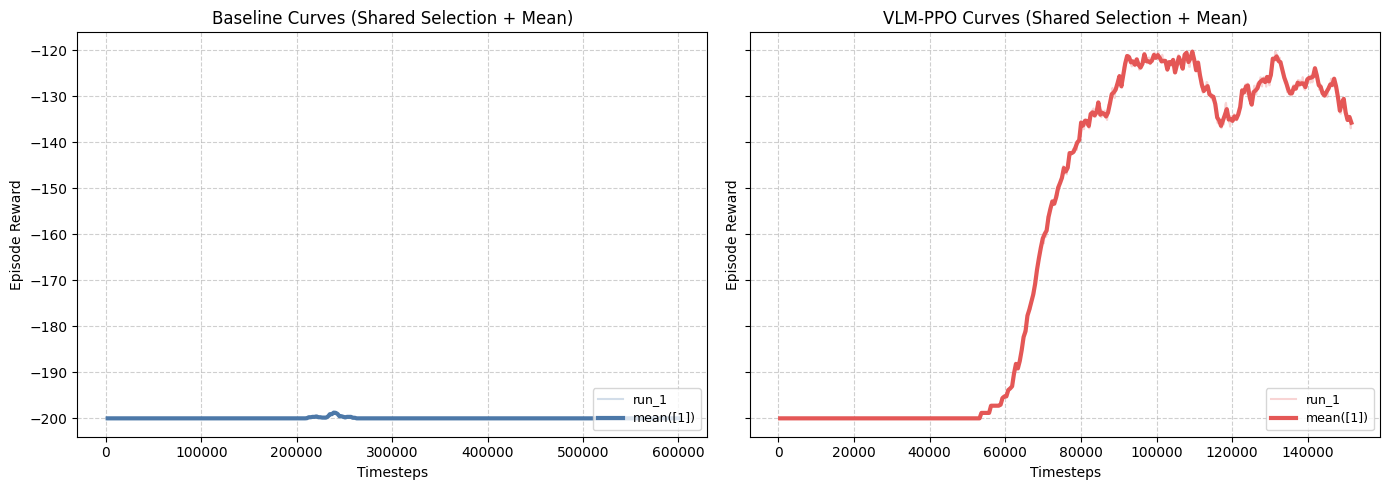

In [12]:
# Cell 3: Interactive training curves with unified run selection
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WINDOW_SIZE = 50
GRID_POINTS = 300

start_dir = Path.cwd().resolve()
project_root = next((p for p in [start_dir, *start_dir.parents] if (p / "core").is_dir()), start_dir)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from core.train_manager import TrainManager

root_log_dir = project_root / "logs_and_results"
baseline_manager = TrainManager(base_dir=root_log_dir, algo_name="baseline")
vlm_manager = TrainManager(base_dir=root_log_dir, algo_name="vlm")

def safe_input(prompt, default=""):
    try:
        raw = input(prompt).strip()
        return raw if raw else default
    except EOFError:
        return default

def parse_ids_or_range(raw):
    raw = raw.strip()
    if raw == "":
        return None
    if "-" in raw:
        left, right = raw.split("-", 1)
        if left.strip().isdigit() and right.strip().isdigit():
            lo = min(int(left.strip()), int(right.strip()))
            hi = max(int(left.strip()), int(right.strip()))
            return list(range(lo, hi + 1))
    parts = [p.strip() for p in raw.split(",") if p.strip()]
    if parts and all(p.isdigit() for p in parts):
        return [int(p) for p in parts]
    raise ValueError(f"Invalid input: {raw}. Use '1-3' or '1,2,3'.")

def get_smoothed_df(manager, run_id, window_size):
    data_map = manager.load_run_data(run_ids=[run_id])
    item = data_map.get(run_id, {})
    df = item.get("monitor")
    if df is None or df.empty:
        return None
    if "timesteps" not in df.columns and "l" in df.columns:
        df["timesteps"] = df["l"].cumsum()
    if "r" not in df.columns or "timesteps" not in df.columns:
        return None
    out = df[["timesteps", "r"]].copy()
    out["reward_smooth"] = out["r"].rolling(window=window_size, min_periods=1).mean()
    return out

def interpolate_curve(df, x_grid):
    x = df["timesteps"].to_numpy(dtype=float)
    y = df["reward_smooth"].to_numpy(dtype=float)
    if len(x) < 2:
        return None
    y_interp = np.interp(x_grid, x, y, left=np.nan, right=np.nan)
    y_interp[x_grid > np.max(x)] = np.nan
    return y_interp

def plot_runs_and_average(ax, manager, run_ids, avg_ids, color, title):
    run_dfs = {}
    for rid in run_ids:
        sdf = get_smoothed_df(manager, rid, WINDOW_SIZE)
        if sdf is None:
            continue
        run_dfs[rid] = sdf
        ax.plot(
            sdf["timesteps"],
            sdf["reward_smooth"],
            color=color,
            alpha=0.25,
            linewidth=1.5,
            label=f"run_{rid}",
        )

    if not run_dfs:
        ax.set_title(title)
        ax.set_xlabel("Timesteps")
        ax.set_ylabel("Episode Reward")
        ax.grid(True, linestyle="--", alpha=0.6)
        return

    avg_source_ids = [rid for rid in avg_ids if rid in run_dfs]
    if avg_source_ids:
        x_max = min(run_dfs[rid]["timesteps"].max() for rid in avg_source_ids)
        x_grid = np.linspace(0, x_max, GRID_POINTS)
        ys = []
        for rid in avg_source_ids:
            y_interp = interpolate_curve(run_dfs[rid], x_grid)
            if y_interp is not None:
                ys.append(y_interp)
        if ys:
            y_mean = np.nanmean(np.vstack(ys), axis=0)
            ax.plot(x_grid, y_mean, color=color, linewidth=3, label=f"mean({avg_source_ids})")

    ax.set_title(title)
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Episode Reward")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="lower right", fontsize=9)

baseline_all = baseline_manager.list_run_ids()
vlm_all = vlm_manager.list_run_ids()
common_runs = sorted(set(baseline_all).intersection(vlm_all))
print(f"Baseline runs: {baseline_all}")
print(f"VLM runs: {vlm_all}")
print(f"Common runs: {common_runs}")

if not common_runs:
    # Backward compatibility for old single-file layout
    legacy_baseline_csv = root_log_dir / "baseline_monitor.csv"
    legacy_vlm_csv = root_log_dir / "vlm_monitor.csv"

    def legacy_plot(csv_path, label, color):
        if not csv_path.exists():
            print(f"Missing file: {csv_path}")
            return
        df = pd.read_csv(csv_path, skiprows=1)
        df["timesteps"] = df["l"].cumsum()
        smooth = df["r"].rolling(window=WINDOW_SIZE, min_periods=1).mean()
        plt.plot(df["timesteps"], df["r"], color=color, alpha=0.2)
        plt.plot(df["timesteps"], smooth, color=color, linewidth=2, label=label)

    plt.figure(figsize=(10, 6))
    legacy_plot(legacy_baseline_csv, "Baseline PPO (legacy)", "blue")
    legacy_plot(legacy_vlm_csv, "VLM-PPO (legacy)", "red")
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Episode Reward", fontsize=12)
    plt.title("Training Curves: Reward vs. Timesteps (Legacy)", fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    raw_selected = safe_input(
        "Select common runs for curve plot (Enter=all common, e.g. 1-3 or 1,2,4): ",
        default="",
    )
    selected_runs = parse_ids_or_range(raw_selected) if raw_selected else common_runs
    selected_runs = [rid for rid in selected_runs if rid in common_runs]
    if not selected_runs:
        raise ValueError("No valid common runs selected for curves.")
    print(f"Selected common runs: {selected_runs}")

    raw_avg = safe_input(
        "Select ONE common run range/list for curve average (Enter=use selected runs): ",
        default="",
    )
    avg_runs = parse_ids_or_range(raw_avg) if raw_avg else selected_runs
    avg_runs = [rid for rid in avg_runs if rid in selected_runs]
    if not avg_runs:
        raise ValueError("No valid average runs selected for curves.")
    print(f"Curve average runs (shared by baseline and vlm): {avg_runs}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    plot_runs_and_average(
        axes[0],
        baseline_manager,
        selected_runs,
        avg_runs,
        color="#4C78A8",
        title="Baseline Curves (Shared Selection + Mean)",
    )
    plot_runs_and_average(
        axes[1],
        vlm_manager,
        selected_runs,
        avg_runs,
        color="#E45756",
        title="VLM-PPO Curves (Shared Selection + Mean)",
    )
    plt.tight_layout()
    plt.show()